In [27]:
# All libs we need.
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Make some functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)
    
    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_membership_func(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def interp_membership(domain, mf_values, x):
    """
    Equivalent to skfuzzy.interp_membership
    domain: e.g. np.linspace(...)
    mf_values: membership values on that domain
    x: crisp input
    """
    return np.interp(x, domain, mf_values)

def centroid_defuzzification(domain, aggregated_mf):
    """
    Compute centroid defuzzification (discrete version).

    domain: np.ndarray
        The universe of discourse (e.g., domain_difficulty)
    aggregated_mf: np.ndarray
        Aggregated membership values over the domain

    returns: float
        Crisp output (centroid)
    """
    numerator = np.sum(domain * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        # no rule fired → fallback (should rarely happen)
        return np.mean(domain)

    return numerator / denominator



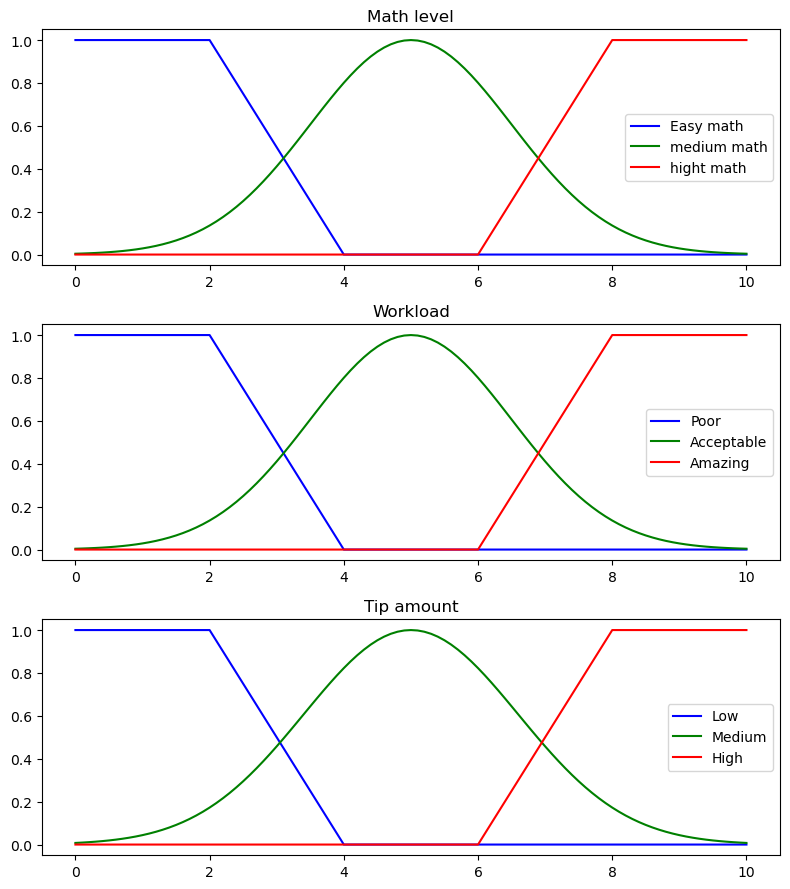

In [29]:


#  Math_level and work_load on subjective ranges [0, 10]
#  Difficulty has a range of [0, 10]

domain_math_level = np.linspace(0, 10, 101) 
domain_workload = np.linspace(0, 10, 101) 
domain_difficulty = np.linspace(0, 10, 101) 


# generate fuzzy membership functions on their corresponding domain.
# These functions are represent by the points and the corresponding values at those points. 
# For simplicity and interpretability, the same membership function shapes were used for all linguistic variables defined on the same normalized domain.

# math level
math_lo_func = trapezoidal_membership_function(domain_math_level, 0, 0, 2, 4)
math_md_func = gauss_membership_func(domain_math_level, 5, 1.5)
math_hi_func = trapezoidal_membership_function(domain_math_level, 6, 8, 10, 10)

# workload
workload_lo_func = trapezoidal_membership_function(domain_workload, 0, 0, 2, 4)
workload_md_func = gauss_membership_func(domain_workload, 5, 1.5)
workload_hi_func = trapezoidal_membership_function(domain_workload, 6, 8, 10, 10)

# course difficulty (output)
difficulty_lo_func = trapezoidal_membership_function(domain_difficulty, 0, 0, 2, 4)
difficulty_md_func = gauss_membership_func(domain_difficulty, 5, 1.6)
difficulty_hi_func = trapezoidal_membership_function(domain_difficulty, 6, 8, 10, 10)

# visualize these universes and membership functions
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9)) # nrows=3 → creates 3 rows of plots (3 charts stacked vertically)

ax0.plot(domain_math_level, math_lo_func, 'b', linewidth=1.5, label='Easy math')
ax0.plot(domain_workload, math_md_func, 'g', linewidth=1.5, label='medium math')
ax0.plot(domain_difficulty, math_hi_func, 'r', linewidth=1.5, label='hight math')
ax0.set_title('Math level')
ax0.legend()

ax1.plot(domain_workload, workload_lo_func, 'b', linewidth=1.5, label='Poor')
ax1.plot(domain_workload, workload_md_func, 'g', linewidth=1.5, label='Acceptable')
ax1.plot(domain_workload, workload_hi_func, 'r', linewidth=1.5, label='Amazing')
ax1.set_title('Workload')
ax1.legend()

ax2.plot(domain_difficulty, difficulty_lo_func, 'b', linewidth=1.5, label='Low')
ax2.plot(domain_difficulty, difficulty_md_func, 'g', linewidth=1.5, label='Medium')
ax2.plot(domain_difficulty, difficulty_hi_func, 'r', linewidth=1.5, label='High')
ax2.set_title('Tip amount')
ax2.legend()

plt.tight_layout()

## Asymmetric Fuzzy Rule Base for Course Difficulty Estimation

In this fuzzy inference system, the rule base was intentionally designed to be **asymmetric**, reflecting the assumption that **mathematical rigor has a stronger impact on course difficulty than workload alone**. While both factors contribute to difficulty, high mathematical requirements are considered more “critical” than a heavy workload.

### Design Assumptions

- High mathematical rigor is more likely to make a course difficult than high workload.
- A heavy workload with low mathematical rigor can still result in a relatively difficult course.
- High mathematical rigor with low workload leads to moderate difficulty rather than extreme difficulty.
- When both factors are low, the course is expected to be easy.
- 
- The main difference is: High level math itself can lead to a difficult course, even if the workload is low. 
- However, although workload is high, if the math is easy, the course wouldn't be extremely difficult. 


---

### Fuzzy Rule Set

1. **R1**  
   IF *math level* is **high**,  
   THEN *course difficulty* is **high**.

2. **R2**  
   IF *workload* is **high** AND *math level* is **medium**,  
   THEN *course difficulty* is **high**.

3. **R3**  
   IF *math level* is **high** AND *workload* is **high**,  
   THEN *course difficulty* is **high**.

4. **R4**  
   IF *math level* is **high** AND *workload* is **low**,  
   THEN *course difficulty* is **medium**.

5. **R5**  
   IF *math level* is **low** AND *workload* is **high**,  
   THEN *course difficulty* is **medium**.

6. **R6**  
   IF *math level* is **medium** AND *workload* is **medium**,  
   THEN *course difficulty* is **medium**.

7. **R7**  
   IF *math level* is **low** AND *workload* is **low**,  
   THEN *course difficulty* is **low**.

---

### Rationale

This rule base captures both dominant and interaction effects between the input variables. By prioritizing mathematical rigor over workload, the fuzzy system models course difficulty in a way that aligns with common academic experience. The rules are interpretable, cover the full input space, and are well suited for Mamdani-style fuzzy inference using the AND operator f


New input
- math level = 6.5
- workload = 9.8

In [30]:
math_level_input = 7
workload_input = 7.5

Math level membership values
Math simple:  0.0
Math medium:  0.41111229050718745
Math high:  0.5


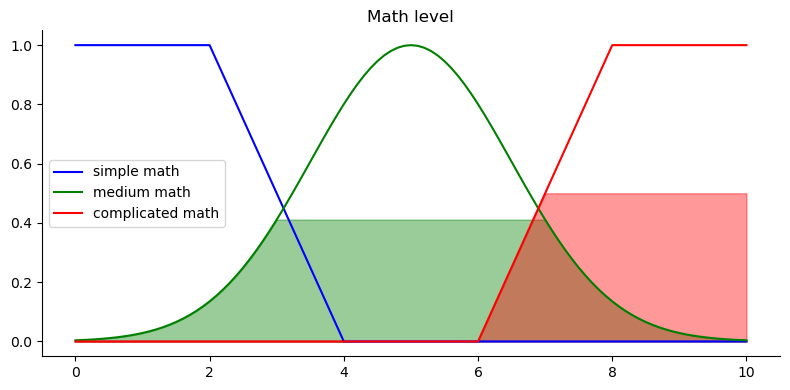

In [31]:
### we need the activation of our fuzzy membership functions at these values.

math_level_lo_firing = interp_membership(domain_math_level, math_lo_func, math_level_input)
math_level_md_firing = interp_membership(domain_math_level, math_md_func, math_level_input)
math_level_hi_firing = interp_membership(domain_math_level, math_hi_func, math_level_input)

print('Math level membership values')
print('Math simple: ',math_level_lo_firing)
print('Math medium: ',math_level_md_firing)
print('Math high: ',math_level_hi_firing)

# Remark:
# qual_lo_func: the original fuzzy set “Bad quality” membership function (a vector of membership values for many x points)
# qual_level_lo_value: a constant value equal to the firing strength (something like 0.3 or 0.5)

# visualize these universes and membership functions
fig, ax0 = plt.subplots(nrows=1, figsize=(8, 4))

ax0.plot(domain_math_level, math_lo_func, 'b', linewidth=1.5, label='simple math')
math_lo_values = np.minimum(math_lo_func,math_level_lo_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_math_level, math_lo_values,color="blue",alpha=0.4)

ax0.plot(domain_math_level, math_md_func, 'g', linewidth=1.5, label='medium math')
math_md_values = np.minimum(math_md_func,math_level_md_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_math_level, math_md_values,color="green",alpha=0.4)

ax0.plot(domain_math_level, math_hi_func, 'r', linewidth=1.5, label='complicated math')
math_hi_values = np.minimum(math_hi_func,math_level_hi_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_math_level, math_hi_values,color="red",alpha=0.4)

ax0.set_title('Math level')
ax0.legend()

# turn off top/right axes
for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

workload membership values
Workload low:  0.0
Workload medium:  0.24935220877729616
Workload heavy:  0.75


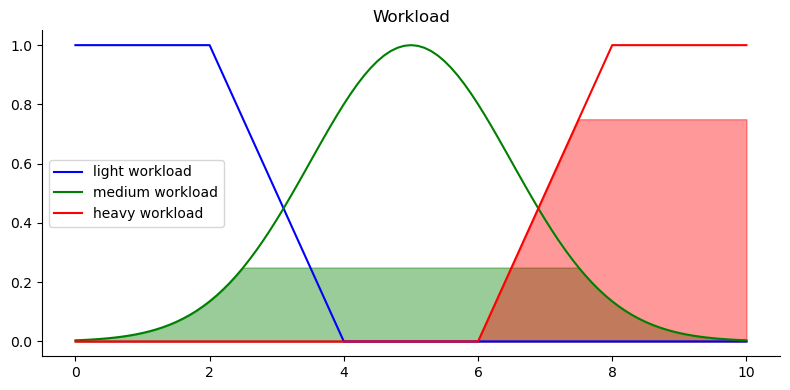

In [32]:
# Show the workload membership functions.

workload_lo_firing = interp_membership(domain_workload, workload_lo_func, workload_input)
workload_md_firing = interp_membership(domain_workload, workload_md_func, workload_input)
workload_hi_firing = interp_membership(domain_workload, workload_hi_func, workload_input)

print('workload membership values')
print('Workload low: ',workload_lo_firing)
print('Workload medium: ',workload_md_firing)
print('Workload heavy: ',workload_hi_firing)

# visualize these universes and membership functions
fig, ax0 = plt.subplots(nrows=1, figsize=(8, 4))

ax0.plot(domain_workload, workload_lo_func, 'b', linewidth=1.5, label='light workload')
workload_lo_values = np.minimum(workload_lo_func,workload_lo_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_workload, workload_lo_values,color="blue",alpha=0.4)

ax0.plot(domain_workload, workload_md_func, 'g', linewidth=1.5, label='medium workload')
workload_md_values = np.minimum(workload_md_func,workload_md_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_workload, workload_md_values,color="green",alpha=0.4)

ax0.plot(domain_workload, workload_hi_func, 'r', linewidth=1.5, label='heavy workload')
workload_hi_values = np.minimum(workload_hi_func,workload_hi_firing) # Get the min between the firing value and the function value at each point.
ax0.fill_between(domain_workload, workload_hi_values,color="red",alpha=0.4)

# ax0.plot(domain_math_level, math_md_func, 'g', linewidth=1.5, label='medium math')
# math_md_values = np.minimum(math_md_func,math_level_md_firing) # Get the min between the firing value and the function value at each point.
# ax0.fill_between(domain_math_level, math_md_values,color="green",alpha=0.4)

# ax0.plot(domain_math_level, math_hi_func, 'r', linewidth=1.5, label='complicated math')
# math_hi_values = np.minimum(math_hi_func,math_level_hi_firing) # Get the min between the firing value and the function value at each point.
# ax0.fill_between(domain_math_level, math_hi_values,color="red",alpha=0.4)

ax0.set_title('Workload')
ax0.legend()

# turn off top/right axes
for ax in (ax0, ax1):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

### Fuzzy Rule Set

1. **R1**  
   IF *math level* is **high**,  
   THEN *course difficulty* is **high**.

2. **R2**  
   IF *math level* is **medium** AND  *workload* is **high**,  
   THEN *course difficulty* is **high**.

3. **R3**  
   IF *math level* is **medium** AND *workload* is **medium**,  
   THEN *course difficulty* is **medium**.

4. **R4**  
   IF *math level* is **medium** AND *workload* is **low**,  
   THEN *course difficulty* is **medium**.

5. **R5**  
   IF *math level* is **low** AND *workload* is **high**,  
   THEN *course difficulty* is **medium**.

6. **R6**  
   IF *math level* is **low** AND *workload* is **medium**,  
   THEN *course difficulty* is **low**.

7. **R7**  
   IF *math level* is **low** AND *workload* is **low**,  
   THEN *course difficulty* is **low**.

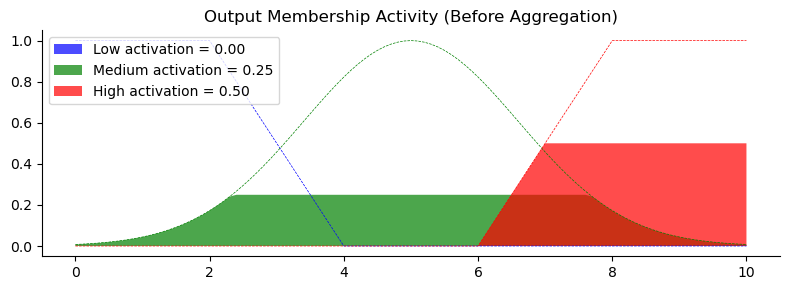

In [33]:
# now we take our rules and apply them. 
# Let each inpuyt numeric value fire the corresponding antecedent clause, take the minimun firing strength, and use that minimun to chop off the consequent clause fuzzy set.

# Rule 1:
activation_Rule1 = math_level_hi_firing # Since there in only one antecedent clause, no need to get the minimun. Just to be consistent.
chop_off1 = np.fmin(activation_Rule1 , difficulty_hi_func)

# Rule 2:
activation_Rule2 = np.fmin(math_level_md_firing , workload_hi_firing)
chop_off2 = np.fmin(activation_Rule2 , difficulty_hi_func)

# Rule 3:
activation_Rule3 = np.fmin(math_level_md_firing , workload_md_firing)
chop_off3 = np.fmin(activation_Rule3,difficulty_md_func)

# Rule 4:
activation_Rule4 = np.fmin(math_level_md_firing , workload_lo_firing)
chop_off4 = np.fmin(activation_Rule4,difficulty_md_func)

# Rule 5:
activation_Rule5 = np.fmin(math_level_lo_firing , workload_hi_firing)
chop_off5 = np.fmin(activation_Rule5,difficulty_md_func)

# Rule 6:
activation_Rule6 = np.fmin(math_level_lo_firing , workload_md_firing)
chop_off6 = np.fmin(activation_Rule6,difficulty_lo_func)

# Rule 7:
activation_Rule7 = np.fmin(math_level_lo_firing , workload_lo_firing)
chop_off7 = np.fmin(activation_Rule7,difficulty_lo_func)



# group by linguistic output (for visualization only)
difficulty_activation_lo = np.fmax(chop_off6, chop_off7)
difficulty_activation_md = np.fmax.reduce([chop_off3, chop_off4, chop_off5])
difficulty_activation_hi = np.fmax(chop_off1, chop_off2)

fig, ax0 = plt.subplots(figsize=(8, 3))

# LOW (blue)
ax0.fill_between(
    domain_difficulty,
    np.zeros_like(domain_difficulty),
    difficulty_activation_lo,
    facecolor='b',
    alpha=0.7,
    label=f'Low activation = {np.max(difficulty_activation_lo):.2f}'
)
ax0.plot(domain_difficulty, difficulty_lo_func, 'b', linewidth=0.5, linestyle='--')

# MEDIUM (green)
ax0.fill_between(
    domain_difficulty,
    np.zeros_like(domain_difficulty),
    difficulty_activation_md,
    facecolor='g',
    alpha=0.7,
    label=f'Medium activation = {np.max(difficulty_activation_md):.2f}'
)
ax0.plot(domain_difficulty, difficulty_md_func, 'g', linewidth=0.5, linestyle='--')

# HIGH (red)
ax0.fill_between(
    domain_difficulty,
    np.zeros_like(domain_difficulty),
    difficulty_activation_hi,
    facecolor='r',
    alpha=0.7,
    label=f'High activation = {np.max(difficulty_activation_hi):.2f}'
)
ax0.plot(domain_difficulty, difficulty_hi_func, 'r', linewidth=0.5, linestyle='--')

ax0.set_title('Output Membership Activity (Before Aggregation)')
ax0.legend(loc='upper left')

# turn off top/right axes
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.get_xaxis().tick_bottom()
ax0.get_yaxis().tick_left()

plt.tight_layout()
plt.show()




**Rule aggregation and defuzzification**

*The core of the FLS*

Lets combine these rules then defuzzify to get a crisp answer from our fuzzy result

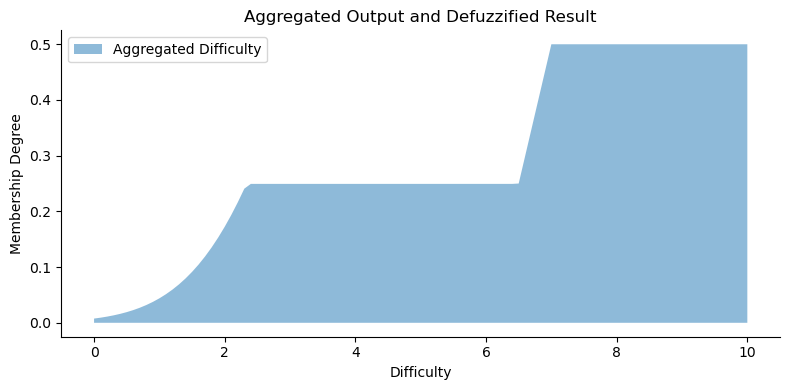

In [ ]:
# aggregate all 7 output membership functions together
# We use the max aggregation(7.13) here instead of the summation(7.12)
# At each point, 
aggregated_difficulty = np.maximum.reduce([
    chop_off1,
    chop_off2,
    chop_off3,
    chop_off4,
    chop_off5,
    chop_off6,
    chop_off7
])

fig, ax = plt.subplots(figsize=(8, 4))

# aggregated fuzzy set
ax.fill_between(
    domain_difficulty,
    aggregated_difficulty,
    alpha=0.5,
    label='Aggregated Difficulty'
)

# centroid (crisp output)
ax.axvline(
    difficulty_crisp,
    color='k',
    linewidth=1.5,
    linestyle='--',
    label='Centroid'
)

ax.set_title('Aggregated Output and Defuzzified Result')
ax.set_xlabel('Difficulty')
ax.set_ylabel('Membership Degree')
ax.legend()

# clean style (same as老师)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()